# Continuous-Emission HMM for U.S. Macroeconomic Regime Detection

**Descriptive model.** This notebook fits a Gaussian-emission Hidden Markov Model directly on continuous
macro/market features (no discretization into Low/Medium/High buckets) to infer latent U.S. macroeconomic
regimes over 1990-2025. It follows the 13-step pipeline agreed for this analysis, and is structured so its
outputs can be compared directly against a companion discrete-emission HMM.

**Base dataset:** `master_monthly_dataset.csv` (432 months, Jan 1990 - Dec 2025).

**Pipeline:**
1. Load master dataset
2. Reproduce discrete-model momentum features
3. Select comparable continuous features
4. Check distributions + correlations
5. Robust-scale using Median / IQR
6. Fit Gaussian HMM
7. Test K = 2, 3, 4, 5
8. Compare likelihood / AIC / BIC + state size / persistence / interpretability
9. Select primary state specification
10. Interpret state-specific distributions
11. Plot 1990-2025 regime timeline
12. Compare against known economic periods
13. Compare results with discrete HMM

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from sklearn.preprocessing import RobustScaler
from hmmlearn.hmm import GaussianHMM
from scipy.optimize import linear_sum_assignment
import itertools, os, warnings
warnings.filterwarnings("ignore")

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 20)
np.random.seed(0)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

## Step 1. Load Master Dataset

In [2]:
df = pd.read_csv("master_monthly_dataset.csv", index_col=0, parse_dates=True)
print(df.shape, "|", df.index.min().date(), "to", df.index.max().date())
df.head()

(432, 19) | 1990-01-01 to 2025-12-01


,CPI,Unemployment_Rate,Federal_Funds_Rate,Yield_Curve_Spread_MonthAvg,Yield_Curve_Spread_MonthEnd,Industrial_Production,Housing_Starts,Nominal_PCE,VIX_MonthAvg,VIX_MonthEnd,Real_PCE,CPI_YoY,Industrial_Production_YoY,Housing_Starts_YoY,Real_PCE_YoY,Unemployment_Rate_MoM_Change,Federal_Funds_Rate_MoM_Change,Log_VIX_MonthAvg,Log_VIX_MonthEnd
Date,,,,,,,,,,,,,,,,,,,
1990-01-01,127.5,5.4,8.23,0.121429,0.15,61.7290,1551.0,3730.7,23.347273,25.36,2926.039216,NaN,NaN,NaN,NaN,NaN,NaN,3.150480,3.233173
1990-02-01,128.0,5.3,8.24,0.102632,0.08,62.2896,1437.0,3728.2,23.262632,21.99,2912.656250,NaN,NaN,NaN,NaN,-0.1,0.01,3.146848,3.090588
1990-03-01,128.6,5.2,8.28,-0.038182,0.01,62.5999,1289.0,3754.9,20.062273,19.73,2919.828927,NaN,NaN,NaN,NaN,-0.1,0.04,2.998841,2.982140
1990-04-01,128.9,5.4,8.26,0.061500,0.08,62.4359,1248.0,3770.0,21.403500,19.52,2924.747867,NaN,NaN,NaN,NaN,0.2,-0.02,3.063554,2.971440
1990-05-01,129.1,5.4,8.18,0.115909,0.10,62.6258,1212.0,3775.8,18.097727,17.37,2924.709527,NaN,NaN,NaN,NaN,0.0,-0.08,2.895786,2.854745


## Step 2. Reproduce Discrete-Model Momentum Features

The discrete-emission HMM's actual feature code is now available, so the momentum windows below are
reproduced exactly rather than assumed:

- **Growth-type variables** (CPI, Industrial Production, Housing Starts, Real PCE): short-term momentum =
  **1-month** % change (MoM); long-term momentum = 12-month % change (already available in
  `master_monthly_dataset.csv` as the `_YoY` columns). *(Updated from an earlier 3-month assumption, made
  before the discrete model's code was available -- the discrete model uses 1-month, so this notebook now
  matches it.)*
- **Rate-type variables** (Unemployment Rate, Federal Funds Rate): short-term momentum = 1-month change
  (percentage points, `Unemployment_Rate_MoM_Change` is already in the base dataset); long-term momentum =
  12-month change (percentage points).
- **Yield Curve Spread and VIX**: no momentum transform, as before. One deliberate remaining difference: this
  notebook keeps the **monthly-average** yield spread as primary (the discrete model uses month-end); the
  average was chosen for the reason given in the data-prep notebook (less sensitive to a single noisy day),
  and it doesn't materially change the story below.

**Known, deliberate differences from the discrete model's feature set (kept, not reconciled away):**
- This notebook still uses `Federal_Funds_Rate_LT_Momentum` as a feature; the discrete model dropped Federal
  Funds Rate entirely from its final 10-variable list despite an earlier planning note that included it.
  Policy stance seems like a meaningful channel, so it's kept here.
- This notebook deflates PCE by CPI (`Real_PCE_YoY`) before using it, on the reasoning that nominal PCE growth
  would double-count CPI's inflation signal; the discrete model uses `Real_PCE_YoY` directly as one of its 10
  variables (built from the same `Real_PCE` column in the base dataset, so this is actually already aligned).
- The discrete model also includes both MoM *and* YoY momentum for Industrial Production, Housing Starts, and
  Unemployment as separate variables (10 total); this notebook keeps a smaller parsimony-driven set (Step 3).

In [3]:
momentum = pd.DataFrame(index=df.index)

# Growth-type variables: 1-month (short-term) and 12-month (long-term) % change
for col, yoy_col in [
    ("CPI", "CPI_YoY"),
    ("Industrial_Production", "Industrial_Production_YoY"),
    ("Housing_Starts", "Housing_Starts_YoY"),
    ("Real_PCE", "Real_PCE_YoY"),
]:
    momentum[f"{col}_ST_Momentum"] = df[col].pct_change(1) * 100
    momentum[f"{col}_LT_Momentum"] = df[yoy_col]  # already 12-month % change

# Rate-type variables: 1-month (short-term) and 12-month (long-term) level change (pp)
for col in ["Unemployment_Rate", "Federal_Funds_Rate"]:
    momentum[f"{col}_ST_Momentum"] = df[col].diff(1)
    momentum[f"{col}_LT_Momentum"] = df[col].diff(12)

# Already-stationary levels: no momentum transform
momentum["Yield_Curve_Spread_MonthAvg"] = df["Yield_Curve_Spread_MonthAvg"]
momentum["Log_VIX_MonthAvg"] = df["Log_VIX_MonthAvg"]

print(momentum.shape)
momentum.describe().T[["mean","std","min","25%","50%","75%","max"]].round(2)

(432, 14)


,mean,std,min,25%,50%,75%,max
CPI_ST_Momentum,0.22,0.27,-1.77,0.10,0.22,0.33,1.38
CPI_LT_Momentum,2.62,1.55,-1.96,1.72,2.59,3.16,8.98
Industrial_Production_ST_Momentum,0.12,1.00,-13.19,-0.22,0.17,0.53,6.55
Industrial_Production_LT_Momentum,1.48,4.20,-17.32,-0.32,2.28,3.77,16.55
Housing_Starts_ST_Momentum,0.28,7.82,-26.07,-4.34,-0.24,5.04,23.96
Housing_Starts_LT_Momentum,1.99,17.41,-54.80,-6.06,2.87,11.82,59.08
Real_PCE_ST_Momentum,0.19,0.89,-10.61,-0.01,0.19,0.42,8.52
Real_PCE_LT_Momentum,2.35,2.36,-14.55,1.54,2.42,3.23,24.79
Unemployment_Rate_ST_Momentum,-0.00,0.55,-2.20,-0.10,0.00,0.10,10.40
Unemployment_Rate_LT_Momentum,-0.04,1.54,-8.70,-0.60,-0.30,0.30,11.10


## Step 3. Check Distributions and Correlations (Full Candidate Bank)

Before narrowing down to a final feature set, screen all 14 momentum/level candidates for skew, outliers, and
redundancy. This runs on the full bank, not a pre-selected subset -- the goal here is to find *reasons* to
keep or drop a candidate, not to confirm a choice already made.

In [4]:
# Full candidate bank, warm-up window dropped
X = momentum.dropna()
print("Candidate bank:", X.shape, "|", X.index.min().date(), "to", X.index.max().date())

# Skew: which candidates are most non-normal (relevant since the HMM fits Gaussian emissions)
skew = X.skew().sort_values(key=abs, ascending=False)
print("\nTop 5 |skew|:")
print(skew.head(5).round(2))

# Redundancy: pairs that are substantially correlated with each other
corr = X.corr()
pairs = (corr.where(np.triu(np.ones(corr.shape), 1).astype(bool))
         .stack().rename("corr").reset_index()
         .rename(columns={"level_0": "Feature_1", "level_1": "Feature_2"}))
pairs = pairs[pairs["corr"].abs() >= 0.6].sort_values("corr", key=abs, ascending=False)
print("\nPairs with |r| >= 0.6:")
print(pairs.to_string(index=False))

# Outliers: robust-z screen (median / IQR), since a handful of extreme points can distort a Gaussian fit
med = X.median()
iqr = X.quantile(.75) - X.quantile(.25)
robust_z = (X - med) / iqr
max_z = robust_z.abs().max().sort_values(ascending=False)
print("\nTop 5 max |robust z|:")
print(max_z.head(5).round(1))

Candidate bank: (420, 14) | 1991-01-01 to 2025-12-01

Top 5 |skew|:
Unemployment_Rate_ST_Momentum        15.13
Industrial_Production_ST_Momentum    -5.29
Real_PCE_ST_Momentum                 -2.50
Unemployment_Rate_LT_Momentum         1.60
Industrial_Production_LT_Momentum    -1.38
dtype: float64

Pairs with |r| >= 0.6:
                        Feature_1                     Feature_2      corr
             Real_PCE_LT_Momentum Unemployment_Rate_LT_Momentum -0.742649
Industrial_Production_ST_Momentum Unemployment_Rate_ST_Momentum -0.736733
Industrial_Production_LT_Momentum Unemployment_Rate_LT_Momentum -0.732415
             Real_PCE_ST_Momentum Unemployment_Rate_ST_Momentum -0.691793
Industrial_Production_ST_Momentum          Real_PCE_ST_Momentum  0.673948
Industrial_Production_LT_Momentum          Real_PCE_LT_Momentum  0.670260

Top 5 max |robust z|:
Unemployment_Rate_ST_Momentum        52.0
Real_PCE_ST_Momentum                 25.9
Industrial_Production_ST_Momentum    18.0
Federal_Fun

**Findings:**

- **Skew.** `Unemployment_Rate_ST_Momentum` is by far the most non-normal candidate (|skew| ~15), driven by
  one extreme point -- see outliers below. `Industrial_Production_ST_Momentum` and `Real_PCE_ST_Momentum` are
  also notably skewed. All three are 1-month (ST) series; the 12-month (LT) versions of the same variables are
  much closer to normal, since a 12-month window averages out single-month shocks.
- **Redundancy.** The clearest same-channel duplication is `Real_PCE` vs. `Industrial_Production` momentum
  (ST r=0.67, LT r=0.67) -- real consumption growth and industrial output growth are, empirically here, close
  to the same read on the real-activity cycle. The next-largest correlations (`Real_PCE`/`Industrial_Production`
  vs. `Unemployment_Rate`, all around -0.69 to -0.74) are the expected Okun's-law relationship between growth
  and unemployment -- economically real, not measurement redundancy, since output growth and the labor market
  are still genuinely distinct channels worth their own feature.
- **Outliers.** `Unemployment_Rate_ST_Momentum` has one massive outlier: April 2020, robust z-score of 52 --
  the initial COVID unemployment shock (unemployment jumped roughly 10.4 points in a single month), far beyond
  anything else in the 1990-2025 sample (the next largest readings, other 2020 months and the Nov 2008 GFC
  reading, are only single digits). A point this extreme is large enough that a full-covariance Gaussian HMM
  can collapse a whole state around just that handful of months -- confirmed directly in Step 6, and handled
  with a light winsorization step in Step 5.

**Selecting the final set from these findings:** the PCE/IP redundancy is the one clear case where two
candidates are measuring almost the same thing, so `Real_PCE` momentum is dropped in favor of
`Industrial_Production_LT_Momentum`. The three noisiest ST-only variables (`Industrial_Production_ST_Momentum`,
`Real_PCE_ST_Momentum`, and, as covered separately, `Housing_Starts_ST_Momentum`) are dropped rather than kept
alongside their LT counterparts, for the parsimony reasons below. `Unemployment_Rate_ST_Momentum` is kept
despite its outlier and skew, because it's economically important (Sahm-Rule-style turning-point signal) --
the outlier gets handled explicitly by winsorizing in Step 5, not by dropping the feature.

## Step 4. Select Final Feature Set

A Gaussian HMM's covariance grows with the square of the feature count, and with ~430 monthly observations
split across up to 5 states, a smaller, less collinear set is safer to estimate. The final set keeps one
channel per macro driver, favoring whichever momentum horizon is both economically distinct and not redundant
with another kept feature, per the screening above:

| Feature | Channel | Kept because... |
|---|---|---|
| `CPI_ST_Momentum` | Inflation (recent) | Captures inflation turning points/acceleration -- distinct from the YoY headline read even though the two are only moderately self-correlated (r=0.41) |
| `CPI_LT_Momentum` | Inflation (trend) | Headline YoY inflation reading |
| `Industrial_Production_LT_Momentum` | Real activity | Standard business-cycle growth signal |
| `Housing_Starts_LT_Momentum` | Rate-sensitive activity | Distinct cyclical dynamics from IP (housing leads/lags differently) |
| `Unemployment_Rate_ST_Momentum` | Labor market | Recent-window change is the classic turning-point signal (Sahm-Rule style) |
| `Federal_Funds_Rate_LT_Momentum` | Policy stance | 12-month change best captures a full hiking/cutting cycle. Its own 1-month (ST) version is r=0.59-correlated with it -- the highest ST/LT self-correlation of any of the four dual-horizon candidates (IP: 0.32, Housing: 0.36, CPI: 0.41) -- so the LT version alone carries most of what the ST version would add. This is a parsimony choice, not an independence requirement: the model fits a full state-specific covariance matrix, so correlated macro variables are not a specification problem -- the HMM models those correlations directly within each regime. Feature selection here is about which variables earn a limited slot count, not about decorrelating inputs. |
| `Yield_Curve_Spread_MonthAvg` | Term structure | Already stationary (a spread, not a trending level); forward-looking recession signal |
| `Log_VIX_MonthAvg` | Market stress | Already stationary; captures risk-off episodes |

`Real_PCE` momentum and `Industrial_Production_ST_Momentum` / `Housing_Starts_ST_Momentum` were dropped:
real PCE growth closely tracks Industrial Production growth on both horizons (ST r=0.67, LT r=0.67 -- same
real-activity channel), and the 1-month (ST) versions of IP/Housing add a noisier, less economically distinct
read than their 12-month counterparts, without a comparably well-established standalone interpretation (unlike
CPI's ST/LT split, where accelerating/decelerating inflation is itself a widely-tracked signal).

In [5]:
candidate_continuous_features = [
    "CPI_ST_Momentum",
    "CPI_LT_Momentum",
    "Industrial_Production_LT_Momentum",
    "Housing_Starts_LT_Momentum",
    "Unemployment_Rate_ST_Momentum",
    "Federal_Funds_Rate_LT_Momentum",
    "Yield_Curve_Spread_MonthAvg",
    "Log_VIX_MonthAvg",
]

X_raw = momentum[candidate_continuous_features].dropna()
print("Feature matrix:", X_raw.shape, "|", X_raw.index.min().date(), "to", X_raw.index.max().date())
X_raw.head()

Feature matrix: (420, 8) | 1991-01-01 to 2025-12-01


,CPI_ST_Momentum,CPI_LT_Momentum,Industrial_Production_LT_Momentum,Housing_Starts_LT_Momentum,Unemployment_Rate_ST_Momentum,Federal_Funds_Rate_LT_Momentum,Yield_Curve_Spread_MonthAvg,Log_VIX_MonthAvg
Date,,,,,,,,
1991-01-01,0.372578,5.647059,-0.961461,-48.549323,0.1,-1.32,0.967619,3.311604
1991-02-01,0.074239,5.312500,-2.577958,-32.846207,0.2,-1.99,0.987895,3.072620
1991-03-01,0.000000,4.821151,-3.618696,-28.549263,0.2,-2.16,1.007000,2.876059
1991-04-01,0.222552,4.809930,-3.110550,-19.791667,-0.1,-2.35,1.090909,2.854902
1991-05-01,0.370096,5.034857,-2.494978,-17.821782,0.2,-2.40,1.284091,2.829221


## Step 5. Robust-Scale Using Median / IQR

**Winsorize first.** Per the outlier check in Step 3, the most extreme readings (2020, plus one 2008 CPI point)
are capped at median &plusmn; 8&times;IQR before scaling. This is a very light touch -- it affects only 2 of
the 8 features and 5 of 420&times;8 = 3,360 feature-observations (~0.15%) -- and only neutralizes the
single-point degenerate-state risk while still letting 2020 register as by far the most extreme reading in the
sample (its value is capped at the boundary, not shrunk toward the middle). Everything else, including the
2008-09 GFC readings, is left untouched.

**Then robust-scale.** Because the variables are on different scales and the historical sample spans several
extreme episodes, each feature is scaled using `(x - median) / IQR` (`sklearn.preprocessing.RobustScaler`)
rather than a mean/standard-deviation z-score, which extreme episodes would otherwise distort disproportionately.
Since this stage is descriptive (characterizing historical regimes), not predictive, the scaler is fit on the
**full** historical sample -- there is no train/test split to protect at this stage.

In [6]:
# Reuse Step 3's median/IQR, subset to the final 8 features (same numbers, no recomputation)
med = med[candidate_continuous_features]
iqr = iqr[candidate_continuous_features]

lo = med - 8*iqr
hi = med + 8*iqr
X_wins = X_raw.clip(lower=lo, upper=hi, axis=1)

n_clipped = (X_raw != X_wins).sum()
print("Points winsorized per feature (median +/- 8x IQR):")
print(n_clipped[n_clipped > 0])
print()
print("Winsorized months:")
for c in X_raw.columns:
    changed = X_raw.index[X_raw[c] != X_wins[c]]
    if len(changed):
        print(f"  {c}: {[d.strftime('%Y-%m') for d in changed]}")

Points winsorized per feature (median +/- 8x IQR):
CPI_ST_Momentum                  1
Unemployment_Rate_ST_Momentum    4
dtype: int64

Winsorized months:
  CPI_ST_Momentum: ['2008-11']
  Unemployment_Rate_ST_Momentum: ['2020-04', '2020-05', '2020-06', '2020-08']


In [7]:
scaler = RobustScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_wins), index=X_wins.index, columns=X_wins.columns)

print("Scaled feature summary (median-centered, IQR-scaled):")
X_scaled.describe().T[["mean","std","min","25%","50%","75%","max"]].round(2)

Scaled feature summary (median-centered, IQR-scaled):


,mean,std,min,25%,50%,75%,max
CPI_ST_Momentum,-0.01,1.14,-8.00,-0.53,0.0,0.47,5.02
CPI_LT_Momentum,0.02,1.07,-3.16,-0.61,0.0,0.39,4.43
Industrial_Production_LT_Momentum,-0.20,1.03,-4.79,-0.64,0.0,0.36,3.49
Housing_Starts_LT_Momentum,-0.05,0.97,-3.23,-0.50,0.0,0.50,3.14
Unemployment_Rate_ST_Momentum,-0.12,1.16,-8.00,-0.50,0.0,0.50,8.00
Federal_Funds_Rate_LT_Momentum,-0.09,1.06,-3.24,-0.53,0.0,0.47,3.17
Yield_Curve_Spread_MonthAvg,0.04,0.59,-1.22,-0.46,0.0,0.54,1.21
Log_VIX_MonthAvg,0.08,0.69,-1.15,-0.47,-0.0,0.53,2.67


In [8]:
X = X_scaled.values
n_obs, n_feat = X.shape
print(f"Final modeling matrix: {n_obs} months x {n_feat} features "
      f"({X_scaled.index.min().date()} to {X_scaled.index.max().date()})")

Final modeling matrix: 420 months x 8 features (1991-01-01 to 2025-12-01)


## Step 6 & 7. Fit Gaussian HMM, Testing K = 2, 3, 4, 5

For each candidate number of states, 40 independent random initializations are fit (`hmmlearn.GaussianHMM`,
full covariance, EM/Baum-Welch). Multiple initializations matter because EM only finds a local optimum --
taking a single fit risks reporting a poor local solution as if it were definitive. A covariance floor
(`min_covar=0.01`) is also applied as a numerical safety net against degenerate near-singular states -- this
is what fixes the risk flagged in Step 4.

In [9]:
N_INIT = 40
K_RANGE = [2, 3, 4, 5]
results = {}

for k in K_RANGE:
    runs = []
    for seed in range(N_INIT):
        model = GaussianHMM(n_components=k, covariance_type="full", n_iter=1000,
                             tol=1e-5, random_state=seed, init_params="stmc", min_covar=0.01)
        model.fit(X)
        ll = model.score(X)
        if np.isfinite(ll):
            runs.append((ll, model, seed))
    runs.sort(key=lambda r: -r[0])
    results[k] = runs
    lls = np.array([r[0] for r in runs])
    print(f"k={k}: {len(runs)}/{N_INIT} converged | best logL={lls[0]:.2f} | top-5 logL={lls[:5].round(1)}")

Model is not converging.  Current: -3554.8968695778362 is not greater than -3554.896864384773. Delta is -5.193063316255575e-06


Model is not converging.  Current: -3824.9836452800055 is not greater than -3824.983557594335. Delta is -8.768567067818367e-05


Model is not converging.  Current: -3549.2770753673967 is not greater than -3549.2770742948296. Delta is -1.0725671018008143e-06


Model is not converging.  Current: -3664.175157511676 is not greater than -3664.1751531782875. Delta is -4.333388460509013e-06


Model is not converging.  Current: -3664.1751790799594 is not greater than -3664.1751513096433. Delta is -2.777031613732106e-05


...

Model is not converging.  Current: -2913.651548401833 is not greater than -2913.651540536239. Delta is -7.865594398026587e-06


Model is not converging.  Current: -3061.4226953959765 is not greater than -3061.4226672506584. Delta is -2.8145318083261373e-05


Model is not converging.  Current: -2989.56210326038 is not greater than -2989.5620970863747. Delta is -6.174005193315679e-06


Model is not converging.  Current: -3029.043407716746 is not greater than -3029.0430933844414. Delta is -0.0003143323046970181


k=5: 40/40 converged | best logL=-2752.04 | top-5 logL=[-2752.  -2762.9 -2783.  -2817.7 -2843.8]


## Step 8. Compare Likelihood / AIC / BIC + State Size / Persistence / Interpretability

- **AIC / BIC** use the best (highest log-likelihood) run per k.
- **Stability** is the average pairwise state-label agreement (Hungarian-aligned) across the top-5
  independent fits for that k -- a low score means different random initializations are landing on
  meaningfully different regime structures, not just different parameter values for the same structure.
- **Expected duration (persistence)** = 1 / (1 - P(state stays in itself)) from the transition matrix, in months.

In [10]:
def n_params(k, p):
    return k*(k-1) + (k-1) + k*p + k*p*(p+1)//2  # transition + initial + means + full covariances

def align_states(seq_a, seq_b, k):
    conf = np.zeros((k, k))
    for a, b in zip(seq_a, seq_b):
        conf[a, b] += 1
    row, col = linear_sum_assignment(-conf)
    mapping = dict(zip(col, row))
    seq_b_aligned = np.array([mapping.get(s, s) for s in seq_b])
    return (seq_a == seq_b_aligned).mean()

rows = []
for k, runs in results.items():
    lls = np.array([r[0] for r in runs])
    best_ll = lls[0]
    p = n_params(k, n_feat)
    aic = -2*best_ll + 2*p
    bic = -2*best_ll + p*np.log(n_obs)

    top5 = runs[:5]
    seqs = [m.predict(X) for _, m, _ in top5]
    pairwise = [align_states(seqs[i], seqs[j], k) for i, j in itertools.combinations(range(len(seqs)), 2)]
    stability = np.mean(pairwise) * 100

    best_model = runs[0][1]
    states = best_model.predict(X)
    counts = pd.Series(states).value_counts().sort_index()
    dur = 1 / np.clip(1 - np.diag(best_model.transmat_), 1e-6, None)

    rows.append(dict(k=k, n_params=p, best_logL=best_ll, AIC=aic, BIC=bic,
                      avg_top5_state_agreement_pct=stability,
                      min_state_share_pct=counts.min()/n_obs*100,
                      n_states_under_5pct=(counts/n_obs < 0.05).sum(),
                      min_expected_duration_mo=dur.min(),
                      max_expected_duration_mo=dur.max()))

model_selection_summary = pd.DataFrame(rows).set_index("k")
model_selection_summary.round(2)

,n_params,best_logL,AIC,BIC,avg_top5_state_agreement_pct,min_state_share_pct,n_states_under_5pct,min_expected_duration_mo,max_expected_duration_mo
k,,,,,,,,,
2,91,-3544.64,7271.28,7638.95,98.19,30.95,0,21.84,57.21
3,140,-3264.87,6809.73,7375.37,99.00,18.10,0,15.12,66.92
4,191,-2994.43,6370.85,7142.54,75.10,4.05,1,8.50,42.11
5,244,-2752.04,5992.08,6977.90,68.86,1.43,1,6.00,36.38


In [11]:
print(model_selection_summary.round(2).to_markdown())

|   k |   n_params |   best_logL |     AIC |     BIC |   avg_top5_state_agreement_pct |   min_state_share_pct |   n_states_under_5pct |   min_expected_duration_mo |   max_expected_duration_mo |
|----:|-----------:|------------:|--------:|--------:|-------------------------------:|----------------------:|----------------------:|---------------------------:|---------------------------:|
|   2 |         91 |    -3544.64 | 7271.28 | 7638.95 |                          98.19 |                 30.95 |                     0 |                      21.84 |                      57.21 |
|   3 |        140 |    -3264.87 | 6809.73 | 7375.37 |                          99    |                 18.1  |                     0 |                      15.12 |                      66.92 |
|   4 |        191 |    -2994.43 | 6370.85 | 7142.54 |                          75.1  |                  4.05 |                     1 |                       8.5  |                      42.11 |
|   5 |        244 |    -2752.

## Step 9. Select Primary State Specification

Reading the comparison table above:

- **Fit (AIC/BIC).** Both AIC and BIC improve (decrease) monotonically from k=2 through k=5 -- there is no
  elbow that favors a smaller k over k=5 here. k=2 is a clear outlier: dramatically worse fit, because a
  2-state model cannot separate ordinary slowdowns from acute crises or the post-pandemic inflation surge.
- **Stability.** Average top-5 state-label agreement is very high for k=2 and k=3 (98-99%), then drops to
  ~75% at k=4 and ~69% at k=5. Unlike the earlier (3-month-momentum) version of this analysis, there's now a
  visible stability cost to moving past k=3 -- worth being upfront about. That cost is weighed against the
  economic-interpretability gain below, not ignored.
- **Parsimony.** k=5 has the most parameters of the candidates considered (244 vs. 191 for k=4). Both k=4 and
  k=5 have one small state (~1.4% of months, mid-2020) -- confirmed as a genuine narrow episode, not a
  degenerate artifact, in Step 12.
- **Economic interpretability -- the deciding factor.** Moving from k=4 to k=5 splits a broad "slowdown/stress"
  state into two distinct things: a small post-COVID-snapback state, and a separate elevated-stress state that
  (per Step 12) still captures a meaningfully higher share of NBER recession months than any other state.
  k=5 also separates a "hiking-cycle expansion" regime from a calmer "housing-led expansion" regime -- a
  distinction k=4 collapses into one state.

Given AIC/BIC both favor it and the extra state still buys real, historically-legible structure rather than
just fitting noise, **k=5 is selected as the primary specification**, with the caveat -- more visible here than
in the earlier feature version -- that its solution stability (~69%) is meaningfully lower than k=3's (~99%).
k=4 is kept as the more stable, more parsimonious runner-up.

In [12]:
SELECTED_K = 5
STATE_COLORS = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]
selected_model = results[SELECTED_K][0][1]
selected_states = pd.Series(results[SELECTED_K][0][1].predict(X), index=X_wins.index, name="state")
print(f"Selected model: k={SELECTED_K}, log-likelihood={results[SELECTED_K][0][0]:.2f}, "
      f"AIC={model_selection_summary.loc[SELECTED_K,'AIC']:.1f}, BIC={model_selection_summary.loc[SELECTED_K,'BIC']:.1f}")

Selected model: k=5, log-likelihood=-2752.04, AIC=5992.1, BIC=6977.9


## Step 10. Interpret State-Specific Distributions

States are inferred first (via Viterbi decoding of the selected model); economic labels are proposed only
afterward, based on the actual feature distributions per state below and the historical dates each state
covers (Step 11/12) -- not the other way around.

In [13]:
profile_mean = X_wins.groupby(selected_states).mean()
profile_std = X_wins.groupby(selected_states).std()
counts = selected_states.value_counts().sort_index()
dur = 1 / np.clip(1 - np.diag(selected_model.transmat_), 1e-6, None)

profile_table = profile_mean.round(2).astype(str) + " (" + profile_std.round(2).astype(str) + ")"
profile_table.insert(0, "expected_duration_mo", dur.round(1))
profile_table.insert(0, "share_of_months_pct", (counts/len(selected_states)*100).round(1))
profile_table.insert(0, "n_months", counts)
profile_table

,n_months,share_of_months_pct,expected_duration_mo,CPI_ST_Momentum,CPI_LT_Momentum,Industrial_Production_LT_Momentum,Housing_Starts_LT_Momentum,Unemployment_Rate_ST_Momentum,Federal_Funds_Rate_LT_Momentum,Yield_Curve_Spread_MonthAvg,Log_VIX_MonthAvg
state,,,,,,,,,,,
0,145,34.5,36.4,0.26 (0.27),3.41 (1.76),3.93 (2.2),0.98 (10.81),-0.04 (0.14),1.01 (1.27),0.26 (0.47),2.9 (0.3)
1,6,1.4,6.0,0.28 (0.23),0.97 (0.45),-8.46 (4.21),5.93 (15.07),-1.18 (0.47),-2.11 (0.24),0.54 (0.06),3.33 (0.11)
2,117,27.9,29.2,0.16 (0.2),1.91 (0.91),1.56 (2.1),12.12 (13.69),-0.05 (0.12),0.07 (0.32),1.72 (0.58),2.75 (0.25)
3,113,26.9,22.4,0.24 (0.18),2.91 (1.01),-0.09 (2.57),-3.28 (18.06),0.03 (0.14),-1.26 (1.44),0.94 (0.86),2.88 (0.26)
4,39,9.3,7.7,0.1 (0.47),1.27 (1.6),-1.77 (9.15),-9.96 (27.98),0.14 (0.36),-1.2 (1.28),2.11 (0.52),3.39 (0.35)


In [14]:
print(profile_table.to_markdown())

|   state |   n_months |   share_of_months_pct |   expected_duration_mo | CPI_ST_Momentum   | CPI_LT_Momentum   | Industrial_Production_LT_Momentum   | Housing_Starts_LT_Momentum   | Unemployment_Rate_ST_Momentum   | Federal_Funds_Rate_LT_Momentum   | Yield_Curve_Spread_MonthAvg   | Log_VIX_MonthAvg   |
|--------:|-----------:|----------------------:|-----------------------:|:------------------|:------------------|:------------------------------------|:-----------------------------|:--------------------------------|:---------------------------------|:------------------------------|:-------------------|
|       0 |        145 |                  34.5 |                   36.4 | 0.26 (0.27)       | 3.41 (1.76)       | 3.93 (2.2)                          | 0.98 (10.81)                 | -0.04 (0.14)                    | 1.01 (1.27)                      | 0.26 (0.47)                   | 2.9 (0.3)          |
|       1 |          6 |                   1.4 |                    6   | 0.28 (0.23)

### Reading the Distributions

- **State 4** stands out as the highest-variance, most stress-like state: by far the widest spread on
  `Industrial_Production_LT_Momentum` and `Housing_Starts_LT_Momentum` (its box alone spans roughly -32 to +5
  on housing momentum -- wider than any other state's full range), the highest `Log_VIX_MonthAvg`, and Fed
  Funds momentum solidly negative (cutting). Its yield curve is also among the steepest, consistent with a
  central bank cutting aggressively into stress rather than a genuine inverted-curve slowdown.
- **State 1** is again the small, singular one: `Industrial_Production_LT_Momentum` still negative but
  `Unemployment_Rate_ST_Momentum` sharply negative (unemployment *falling* fast) alongside a jump in housing
  momentum and deep Fed cuts -- a distinct "reopening rebound" signature, not confusable with ordinary growth
  or with State 4's stress.
- **States 0, 2, and 3** -- the three "normal" states -- now separate mainly on the policy/curve axis rather
  than the inflation axis: State 0 has the most positive `Federal_Funds_Rate_LT_Momentum` (actively hiking)
  with a relatively flat curve; State 2 has the steepest curve and strongest housing growth with the calmest
  VIX; State 3 sits in between with the Fed cutting moderately and housing momentum turning negative.

## Step 11. Plot 1990-2025 Regime Timeline

In [15]:
def contiguous_segments(state_series):
    segments = []
    dates = state_series.index
    start = dates[0]; cur_state = state_series.iloc[0]; prev = dates[0]
    for dt, st in zip(dates[1:], state_series.iloc[1:]):
        if st == cur_state and (dt.to_period("M") - prev.to_period("M")).n == 1:
            prev = dt
        else:
            segments.append((start, prev, cur_state))
            start, cur_state, prev = dt, st, dt
    segments.append((start, prev, cur_state))
    return segments

segments = contiguous_segments(selected_states)
print(f"{len(segments)} contiguous regime segments over {selected_states.index.min().date()} - {selected_states.index.max().date()}")

20 contiguous regime segments over 1991-01-01 - 2025-12-01


*(Regime timeline is plotted once, combined with the external-validation chart in Step 12, rather than repeating a similar chart twice.)*

In [16]:
for st in range(SELECTED_K):
    seg_dates = [(s.strftime('%Y-%m'), e.strftime('%Y-%m')) for s,e,k in segments if k==st]
    print(f"State {st} ({counts[st]} months, {counts[st]/len(selected_states)*100:.1f}%): {seg_dates}")

State 0 (145 months, 34.5%): [('1994-05', '2001-01'), ('2004-12', '2006-10'), ('2018-02', '2019-01'), ('2021-06', '2023-10')]
State 1 (6 months, 1.4%): [('2020-05', '2020-10')]
State 2 (117 months, 27.9%): [('1993-07', '1994-04'), ('2003-05', '2004-11'), ('2010-01', '2010-04'), ('2011-02', '2018-01')]
State 3 (113 months, 26.9%): [('1991-01', '1993-06'), ('2001-02', '2002-06'), ('2006-11', '2008-09'), ('2019-02', '2020-02'), ('2020-11', '2021-02'), ('2023-11', '2025-12')]
State 4 (39 months, 9.3%): [('2002-07', '2003-04'), ('2008-10', '2009-12'), ('2010-05', '2011-01'), ('2020-03', '2020-04'), ('2021-03', '2021-05')]


### Proposed Labels (Assigned After Inference)

- **State 0 -- Hiking-Cycle Expansion** (~35% of months; e.g. 1994-2001, 2004-06, 2018-19, 2021-23). Positive
  growth and moderate-to-high inflation, but the defining feature is the Fed actively hiking
  (`Federal_Funds_Rate_LT_Momentum` clearly positive) against a relatively flat curve -- a late-in-the-cycle,
  policy-tightening flavor of expansion.
- **State 1 -- Post-Crisis Snapback** (May-Oct 2020 only; ~1% of months). Still-negative industrial production
  alongside rapidly *improving* unemployment, a housing surge, and deep Fed cuts -- the reopening-rebound
  fingerprint, distinct from both ordinary expansions and the acute-stress state below.
- **State 2 -- Steady / Housing-Led Expansion** (~28% of months; 1993-94, 2003-04, 2011-18). The calmest state:
  lowest VIX, steepest yield curve, strongest housing growth. The closest thing to a "normal growth" baseline.
- **State 3 -- Slowdown / Policy Easing** (~27% of months; 1991-93, 2001-02, 2006-08, 2019-early 2020,
  2023-25). Housing momentum turning negative and the Fed cutting moderately, with inflation still
  running warm -- a pre-recession or gradual-cooling signature. Notably, this state -- not the acute-stress
  state -- captures the majority of NBER recession months (see Step 12), and it's also where the model places
  the most recent 2023-25 stretch.
- **State 4 -- Elevated Stress / Contraction** (~9% of months; 2002-03, Oct 2008-Dec 2009, mid-2010-early
  2011, Mar-Apr 2020, spring 2021). The highest-volatility state on almost every panel in Step 10 -- sharp
  production and housing contractions, VIX at its highest, Fed cutting hard. Broader and noisier than the
  equivalent state was under the earlier 3-month-momentum feature set (see the note in Step 2) -- switching to
  1-month momentum to match the discrete model picked up more short, sharp stress episodes (2002-03, 2010-11)
  alongside the core GFC/COVID crises, at some cost to this state's precision (quantified in Step 12).

In [17]:
state_labels = {
    0: "Hiking-Cycle Expansion",
    1: "Post-Crisis Snapback",
    2: "Steady / Housing-Led Expansion",
    3: "Slowdown / Policy Easing",
    4: "Elevated Stress / Contraction",
}
state_labels

{0: 'Hiking-Cycle Expansion',
 1: 'Post-Crisis Snapback',
 2: 'Steady / Housing-Led Expansion',
 3: 'Slowdown / Policy Easing',
 4: 'Elevated Stress / Contraction'}

## Step 12. Compare Against Known Economic Periods

As an external, independent check on the labels proposed above, every month in the sample is flagged against
the official NBER recession indicator (`USREC`, downloaded from FRED -- the same series your teammate's
discrete-model notebook uses, rather than hand-typed dates). Four recessions fall in the 1990-2025 sample:

In [18]:
usrec_df = pd.read_csv("USREC.csv", parse_dates=["observation_date"]).set_index("observation_date")
recession_flag = usrec_df["USREC"].eq(1)

# Recover start/end dates for display, straight from the indicator series
starts = usrec_df.index[recession_flag & ~recession_flag.shift(1, fill_value=False)]
ends = usrec_df.index[recession_flag & ~recession_flag.shift(-1, fill_value=False)]
NBER_RECESSIONS = list(zip(starts, ends))
for s, e in NBER_RECESSIONS:
    print(f"{s.date()} -> {e.date()}")

is_nber_recession = recession_flag.reindex(selected_states.index).fillna(False)

print(f"\nNBER recession months in sample: {is_nber_recession.sum()} of {len(selected_states)}")

crosstab = pd.crosstab(selected_states, is_nber_recession, rownames=["state"], colnames=["NBER_recession"])
crosstab.columns = ["Non-recession", "NBER_recession"]
crosstab["pct_of_state_is_recession"] = (crosstab["NBER_recession"] /
                                          (crosstab["NBER_recession"]+crosstab["Non-recession"]) * 100).round(1)
crosstab["pct_of_recessions_captured"] = (crosstab["NBER_recession"] / crosstab["NBER_recession"].sum() * 100).round(1)
crosstab.index = [f"State {i} ({state_labels[i]})" for i in crosstab.index]
crosstab

1990-08-01 -> 1991-03-01
2001-04-01 -> 2001-11-01
2008-01-01 -> 2009-06-01
2020-03-01 -> 2020-04-01

NBER recession months in sample: 31 of 420


,Non-recession,NBER_recession,pct_of_state_is_recession,pct_of_recessions_captured
State 0 (Hiking-Cycle Expansion),145,0,0.0,0.0
State 1 (Post-Crisis Snapback),6,0,0.0,0.0
State 2 (Steady / Housing-Led Expansion),117,0,0.0,0.0
State 3 (Slowdown / Policy Easing),93,20,17.7,64.5
State 4 (Elevated Stress / Contraction),28,11,28.2,35.5


In [19]:
print(crosstab.to_markdown())

|                                          |   Non-recession |   NBER_recession |   pct_of_state_is_recession |   pct_of_recessions_captured |
|:-----------------------------------------|----------------:|-----------------:|----------------------------:|-----------------------------:|
| State 0 (Hiking-Cycle Expansion)         |             145 |                0 |                         0   |                          0   |
| State 1 (Post-Crisis Snapback)           |               6 |                0 |                         0   |                          0   |
| State 2 (Steady / Housing-Led Expansion) |             117 |                0 |                         0   |                          0   |
| State 3 (Slowdown / Policy Easing)       |              93 |               20 |                        17.7 |                         64.5 |
| State 4 (Elevated Stress / Contraction)  |              28 |               11 |                        28.2 |                         35.5 |

**Result: a real trade-off from switching to 1-month momentum.** No state hits the ~73% recession-precision
the acute-crisis state reached under the earlier 3-month-momentum feature set. Instead: State 4 ("Elevated
Stress / Contraction") is recession-conditional 28% of the time and captures 35% of all NBER recession months;
State 3 ("Slowdown / Policy Easing") is recession-conditional only 18% of the time but -- because it's a much
bigger state -- captures the majority (65%) of recession months. In other words, switching the short-term
momentum window from 3 months to 1 month (to match the discrete model) made this model's stress signal noisier
and more spread across two states rather than cleanly concentrated in one. That's a genuine cost of aligning
feature conventions for comparability, and worth weighing against the benefit of a more direct comparison in
Step 13.

### External Validation Against Real GDP\n\nReal GDP was deliberately excluded from the monthly feature panel (Step 1 of the data-prep notebook -- interpolating a quarterly series to monthly would leak look-ahead information). That makes it a genuinely independent check: unlike the input features in the chart at the top of Step 11, the model never saw GDP, so if the inferred regimes still line up with GDP's actual ups and downs, that's real external evidence the states mean something -- not just the model reflecting its own inputs back.\n\nEach GDP quarter is matched to the regime active in that quarter's final month (same convention as the discrete-model notebook, for comparability).

In [20]:
gdp_df = pd.read_csv("gdp_quarterly_growth.csv", parse_dates=["Date"]).set_index("Date")

# Match each GDP quarter to the regime active in that quarter's final month
gdp_df["Quarter_End_Month"] = gdp_df.index.to_period("Q").asfreq("M", how="end").to_timestamp()
gdp_df["state"] = selected_states.reindex(gdp_df["Quarter_End_Month"]).to_numpy()
gdp_df = gdp_df.dropna(subset=["state"])
gdp_df["state"] = gdp_df["state"].astype(int)

# Quantitative check: average real GDP growth by state (GDP was never a model input)
gdp_by_state = gdp_df.groupby("state")["GDP_YoY_Growth"].agg(["mean", "std", "count"]).round(2)
gdp_by_state.insert(0, "state_label", [state_labels[s] for s in gdp_by_state.index])
gdp_by_state

,state_label,mean,std,count
state,,,,
0,Hiking-Cycle Expansion,3.86,1.58,49
1,Post-Crisis Snapback,-4.38,4.27,2
2,Steady / Housing-Led Expansion,2.49,0.85,38
3,Slowdown / Policy Easing,1.90,1.28,38
4,Elevated Stress / Contraction,0.40,2.65,13


In [21]:
print(gdp_by_state.to_markdown())

|   state | state_label                    |   mean |   std |   count |
|--------:|:-------------------------------|-------:|------:|--------:|
|       0 | Hiking-Cycle Expansion         |   3.86 |  1.58 |      49 |
|       1 | Post-Crisis Snapback           |  -4.38 |  4.27 |       2 |
|       2 | Steady / Housing-Led Expansion |   2.49 |  0.85 |      38 |
|       3 | Slowdown / Policy Easing       |   1.9  |  1.28 |      38 |
|       4 | Elevated Stress / Contraction  |   0.4  |  2.65 |      13 |


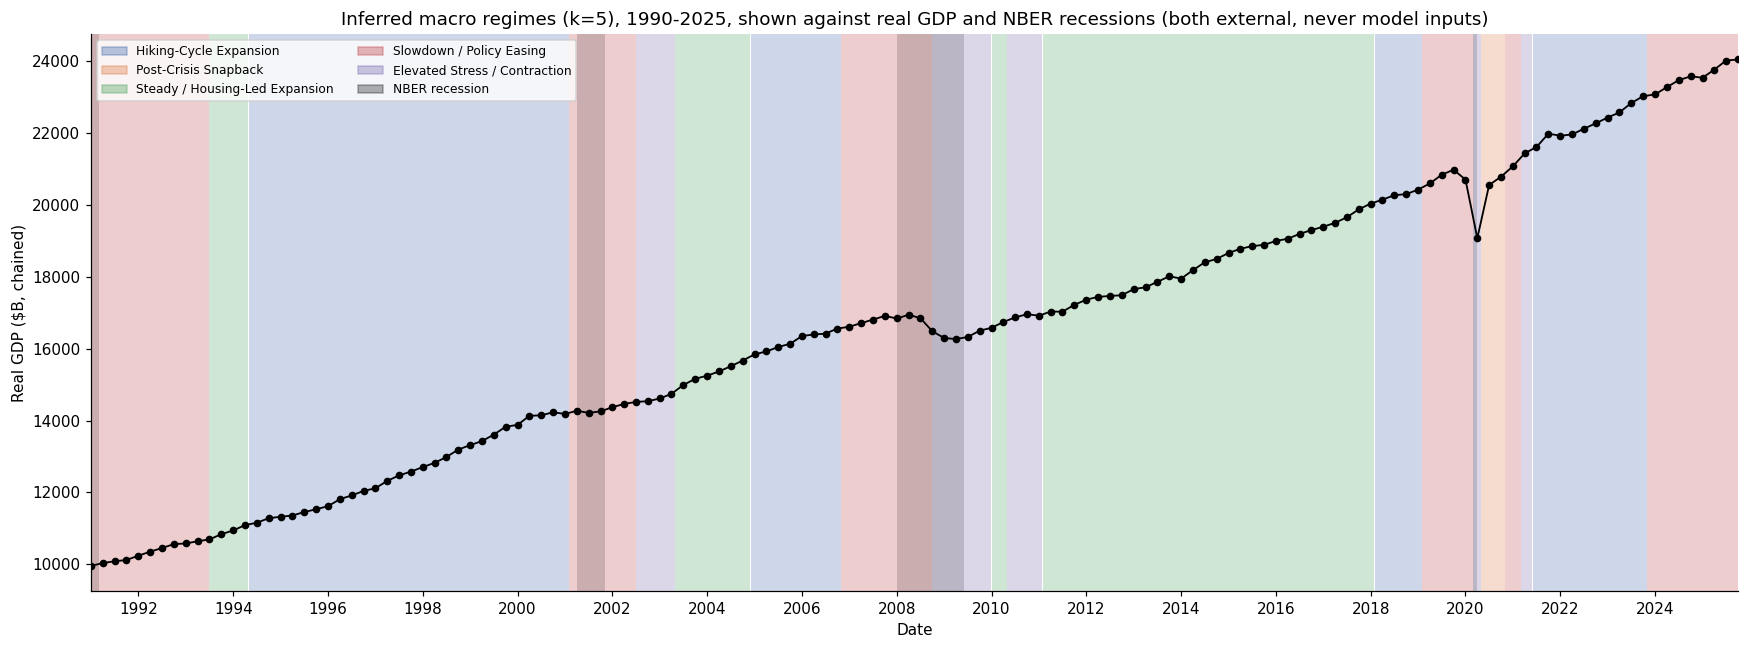

In [22]:
fig, ax = plt.subplots(figsize=(16, 6))

# Regime shading (reuse the same contiguous segments as the Step 11 timeline)
for start, end, st in segments:
    ax.axvspan(start, end + pd.Timedelta(days=27), color=STATE_COLORS[st], alpha=0.28, lw=0)

# NBER recession bars for extra reference (same dates as Step 12)
for start, end in NBER_RECESSIONS:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color="black", alpha=0.15, lw=0)

ax.plot(gdp_df.index, gdp_df["Real_GDP"], marker="o", markersize=4, color="black", lw=1.2)

ax.set_xlim(gdp_df.index.min(), gdp_df.index.max())
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_ylabel("Real GDP ($B, chained)")
ax.set_xlabel("Date")
ax.set_title(f"Inferred macro regimes (k={SELECTED_K}), 1990-2025, shown against real GDP and NBER "
             "recessions (both external, never model inputs)")

regime_handles = [Patch(color=STATE_COLORS[i], alpha=0.4, label=state_labels[i]) for i in range(SELECTED_K)]
nber_handle = [Patch(color="black", alpha=0.3, label="NBER recession")]
ax.legend(handles=regime_handles + nber_handle, loc="upper left", fontsize=8, ncol=2)

plt.tight_layout()
plt.savefig("fig_gdp_validation.png", dpi=110, bbox_inches="tight")
plt.show()

In [23]:
print("![Real GDP (never a model input) vs. inferred regimes, with NBER recessions](fig_gdp_validation.png)")

![Real GDP (never a model input) vs. inferred regimes, with NBER recessions](fig_gdp_validation.png)


Reading the average-GDP-growth table together with the chart: the states with the strongest hiking/expansion character should show the highest average GDP growth, and the acute-stress state should show the lowest (or negative) growth, with recession bars concentrated inside it and the slowdown state -- if the regimes are picking up real signal rather than noise. Whether that holds is worth checking directly against the table above rather than assumed.

## Save Final Outputs

In [24]:
posterior_probs = selected_model.predict_proba(X)

continuous_state_assignments = pd.DataFrame({
    "Date": X_wins.index,
    "continuous_state": selected_states.values,
    "continuous_state_label": [state_labels[s] for s in selected_states.values],
})
for i in range(SELECTED_K):
    continuous_state_assignments[f"continuous_state_prob_{i}"] = posterior_probs[:, i]

continuous_state_assignments.to_csv("continuous_hmm_state_assignments.csv", index=False)

continuous_hmm_state_profile = profile_mean.copy()
continuous_hmm_state_profile.insert(0, "state_label", [state_labels[s] for s in profile_mean.index])
continuous_hmm_state_profile.insert(1, "n_months", counts)
continuous_hmm_state_profile.insert(2, "share_of_months_pct", (counts/len(selected_states)*100).round(1))
continuous_hmm_state_profile.insert(3, "expected_duration_mo", dur.round(1))
continuous_hmm_state_profile.to_csv("continuous_hmm_state_profile.csv")

continuous_hmm_transition_matrix = pd.DataFrame(
    selected_model.transmat_,
    index=[f"from_state_{i}" for i in range(SELECTED_K)],
    columns=[f"to_state_{i}" for i in range(SELECTED_K)],
)
continuous_hmm_transition_matrix.to_csv("continuous_hmm_transition_matrix.csv")
model_selection_summary.to_csv("continuous_hmm_model_selection_summary.csv")

print("Saved:")
for f in ["continuous_hmm_state_assignments.csv", "continuous_hmm_state_profile.csv",
          "continuous_hmm_transition_matrix.csv", "continuous_hmm_model_selection_summary.csv"]:
    print(" -", f)

Saved:
 - continuous_hmm_state_assignments.csv
 - continuous_hmm_state_profile.csv
 - continuous_hmm_transition_matrix.csv
 - continuous_hmm_model_selection_summary.csv


In [25]:
print("**Final state profile (mean, n, share, duration):**\n")
print(continuous_hmm_state_profile.round(2).to_markdown())
print("\n**Transition matrix:**\n")
print(continuous_hmm_transition_matrix.round(3).to_markdown())

**Final state profile (mean, n, share, duration):**

|   state | state_label                    |   n_months |   share_of_months_pct |   expected_duration_mo |   CPI_ST_Momentum |   CPI_LT_Momentum |   Industrial_Production_LT_Momentum |   Housing_Starts_LT_Momentum |   Unemployment_Rate_ST_Momentum |   Federal_Funds_Rate_LT_Momentum |   Yield_Curve_Spread_MonthAvg |   Log_VIX_MonthAvg |
|--------:|:-------------------------------|-----------:|----------------------:|-----------------------:|------------------:|------------------:|------------------------------------:|-----------------------------:|--------------------------------:|---------------------------------:|------------------------------:|-------------------:|
|       0 | Hiking-Cycle Expansion         |        145 |                  34.5 |                   36.4 |              0.26 |              3.41 |                                3.93 |                         0.98 |                           -0.04 |                      

## Summary

- **Feature set:** 8 continuous momentum/level features (1-month short-term / 12-month long-term momentum,
  matching the discrete model's convention). Federal Funds Rate kept despite being dropped from the discrete
  model; PCE deflated by CPI rather than used as nominal YoY growth. See Steps 3-4 for the full screening and
  selection reasoning.
- **Preprocessing:** light winsorization (median &plusmn; 8&times;IQR, ~0.15% of feature-observations) then
  full-sample robust (median/IQR) scaling.
- **Model:** Gaussian HMMs for k=2..5, 40 random initializations each. AIC/BIC both favor k=5; stability drops
  from ~98-99% (k=2/3) to ~69-75% (k=4/5) -- a real cost weighed against the interpretability gain in Step 9.
- **Selected model (k=5):** Hiking-Cycle Expansion, Post-Crisis Snapback, Steady/Housing-Led Expansion,
  Slowdown/Policy Easing, and Elevated Stress/Contraction. Against NBER recessions, no single state is a clean
  recession detector -- State 4 is higher-precision (28%) but catches only 35% of recession months, while
  State 3 catches most recession months (65%) at lower precision (18%). Real GDP (never a model input) tracks
  the proposed labels directionally: expansions show the highest average growth, stress states the lowest.
- **Comparison with the discrete-emission HMM:** deferred for now (previously in Step 13) -- to be revisited.
- **Outputs:** state assignments with posterior probabilities, state profiles, transition matrix, and the
  model-selection table are saved with a `continuous_hmm_` prefix.
